# Task 1 – Baseline models

In this section we build baseline models for both targets:

- **Regression**: LinearRegression for the continuous variable `Output`.
- **Classification**: LogisticRegression for the binary variable `Class`.

In this task we:
- use **all** input features `Input1`–`Input400`,
- do **not** apply any pre-processing such as dimensionality reduction or
  feature selection,
- first evaluate performance on the training data,
- then estimate generalization ability using cross-validation,
- and finally briefly discuss the obtained results.

## 1.1 Load data and basic info

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# Path to the dataset file
data_path = "data.csv"

# Load the data into a DataFrame using ';' as a separator
df = pd.read_csv(data_path, sep=";")

print("Shape of the dataset:", df.shape)
print("First columns:", df.columns[:10])
print("\nFirst rows:")
print(df.head())

print("\nColumn dtypes (first 10):")
print(df.dtypes.head(10))

Shape of the dataset: (2000, 402)
First columns: Index(['Class', 'Output', 'Input1', 'Input2', 'Input3', 'Input4', 'Input5',
       'Input6', 'Input7', 'Input8'],
      dtype='str')

First rows:
   Class     Output    Input1    Input2    Input3    Input4    Input5  \
0      0   0.800586 -0.002583  2.184037 -0.322008  1.621241  1.192444   
1      0   2.168475  0.668637  1.373933 -0.476868 -0.724704  0.031162   
2      1  -1.210777 -0.681438 -0.544753  0.441346 -0.019906 -0.192135   
3      1   0.505678 -0.497957  0.720712  0.149120  0.019251  1.377850   
4      1 -10.281033 -1.178544  0.176941  1.112202  1.234189  0.999451   

     Input6    Input7    Input8  ...  Input391  Input392  Input393  Input394  \
0 -0.278356 -0.207366  0.735689  ... -2.140861  1.187660  0.345238 -0.844885   
1 -1.845921  0.784890  1.508526  ... -1.286120 -0.900044 -0.500399 -0.126421   
2 -0.162510 -0.998777  0.686472  ... -0.391605 -0.190147  0.793746 -0.812737   
3  0.981337 -0.846813  0.036790  ... -0.176734

## 1.2 Preparing features and target variables

The dataset contains:
- a binary target variable `Class` (0/1),
- a continuous target variable `Output`,
- 400 input variables named `Input1`, `Input2`, ..., `Input400`.

In this step we:
- construct the feature matrix `X` from all columns whose names start
  with `"Input"`,
- define `y_class` as the target vector for classification (`Class`),
- define `y_reg` as the target vector for regression (`Output`).

In [2]:
# Collect all input feature columns (those starting with "Input")
input_cols = [col for col in df.columns if col.startswith("Input")]

print("Number of input features:", len(input_cols))

# Feature matrix
X = df[input_cols].values

# Target vectors
y_class = df["Class"].values
y_reg = df["Output"].values

print("Shape of X:", X.shape)
print("Shape of y_class:", y_class.shape)
print("Shape of y_reg:", y_reg.shape)

Number of input features: 400
Shape of X: (2000, 400)
Shape of y_class: (2000,)
Shape of y_reg: (2000,)


## 1.3 Baseline regression – LinearRegression (training set only)

As a baseline regression model for `Output` we use
`LinearRegression`.

In this step:
- we fit the model on the entire training dataset using all input features,
- we predict on the same training data,
- we compute the coefficient of determination R^2 on the training set.

This gives a **naive** estimate of performance, which will typically be
optimistic because it does not use a separate validation or test set.

In [3]:
# Initialize and fit the baseline linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y_reg)

# Predict on the training data
y_reg_pred_train = lin_reg.predict(X)

# Compute R^2 on the training data
r2_train_reg = r2_score(y_reg, y_reg_pred_train)

print("Baseline regression (LinearRegression) – R^2 on training data:", r2_train_reg)

Baseline regression (LinearRegression) – R^2 on training data: 0.6079625367893318


### Baseline regression – estimating generalization with cross-validation

To estimate how well the baseline regression model generalizes beyond
the training data, we use K-fold cross-validation.

Procedure:
1. Split the dataset into `K` folds (here we will use `K = 5`).
2. For each fold:
   - train `LinearRegression` on `K-1` folds,
   - evaluate on the remaining validation fold using `R^2`.
3. Aggregate the results by computing the mean and standard deviation
   of the cross-validated `R^2` scores.

This provides an approximate, less biased estimate of the model's
generalization performance. In this project I use regular KFold because the dataset is relatively large and the classes are approximately balanced, so simple random splits already preserve the class proportions reasonably well.
For strongly imbalanced classification problems, I would instead prefer to use StratifiedKFold, which explicitly maintains similar class distributions in each fold and therefore provides more reliable and stable estimates of model performance

In [4]:
# Define K-fold cross-validation with shuffling for more robustness
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# cross_val_score will:
# - split the data according to KFold,
# - train LinearRegression on each training fold,
# - evaluate R^2 on the validation fold.
cv_scores_reg = cross_val_score(
    estimator=LinearRegression(),
    X=X,
    y=y_reg,
    cv=kf,
    scoring="r2",
)

print(f"Baseline regression – R^2 CV scores (K={k_folds}):", cv_scores_reg)
print("Baseline regression – mean R^2 (CV):", cv_scores_reg.mean())
print("Baseline regression – std R^2 (CV):", cv_scores_reg.std())

Baseline regression – R^2 CV scores (K=5): [0.44639907 0.29950736 0.41776171 0.30042468 0.41067916]
Baseline regression – mean R^2 (CV): 0.37495439822050736
Baseline regression – std R^2 (CV): 0.06238589862665438


## 1.4 Baseline classification – LogisticRegression (training set only)

For the classification task with target `Class` we use logistic regression as the baseline model.

In this step:
- we fit logistic regression using all input features,
- we evaluate it on the training data using accuracy,
- we obtain the classification accuracy on the training set.

Again, this is a **training** performance, which is usually optimistic.
We will later perform cross-validation to estimate generalization.

In [5]:
# Initialize logistic regression.
# We set a higher max_iter to ensure convergence with many features.
log_reg = LogisticRegression(max_iter=1000)

# Fit logistic regression on all training data
log_reg.fit(X, y_class)

# Predict class labels on training data
y_class_pred_train = log_reg.predict(X)

# Compute training accuracy
accuracy_train_class = accuracy_score(y_class, y_class_pred_train)

print("Baseline classification (LogisticRegression) – accuracy on training data:",
      accuracy_train_class)

Baseline classification (LogisticRegression) – accuracy on training data: 0.71


### Baseline classification – estimating generalization with cross-validation

To estimate how well the baseline logistic regression model generalizes,
we again use K-fold cross-validation (with the same `K = 5`).

Procedure:
1. Split the dataset into 5 folds using `KFold` with shuffling.
2. For each fold:
   - train `LogisticRegression` on 4 folds,
   - evaluate on the remaining fold using **accuracy**.
3. Aggregate accuracies over all folds (mean and standard deviation).

This gives a more realistic estimate of performance on unseen data
than using only the training accuracy.

In [6]:
kf_class = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# cross_val_score will:
# - split the data into folds,
# - fit LogisticRegression on each training fold,
# - evaluate accuracy on the validation fold.
cv_scores_class = cross_val_score(
    estimator=LogisticRegression(max_iter=1000),
    X=X,
    y=y_class,
    cv=kf_class,
    scoring="accuracy",
)

print(f"Baseline classification – accuracy CV scores (K={k_folds}):", cv_scores_class)
print("Baseline classification – mean accuracy (CV):", cv_scores_class.mean())
print("Baseline classification – std accuracy (CV):", cv_scores_class.std())

Baseline classification – accuracy CV scores (K=5): [0.5175 0.4775 0.5375 0.53   0.5225]
Baseline classification – mean accuracy (CV): 0.517
Baseline classification – std accuracy (CV): 0.020880613017821105


### 1.5 Summary and role of baseline models

In summary, the baseline linear regression model achieves a moderate
cross-validated R^2 (around 0.37), indicating that a simple linear
relationship between inputs and `Output` explains a limited
portion of the variance. The gap between training and cross-validated
performance suggests some degree of overfitting.

The baseline logistic regression classifier reaches a training accuracy of
approximately 0.71 and a slightly lower cross-validated accuracy, confirming
that it captures useful information from the features but still falls short
of the performance to the 0.8 from task. This baseline
provides a reference point to which more advanced
classification models.

To better illustrate the difference between training and cross-validated performance,
I compare both metrics for the baseline classification and regression models.

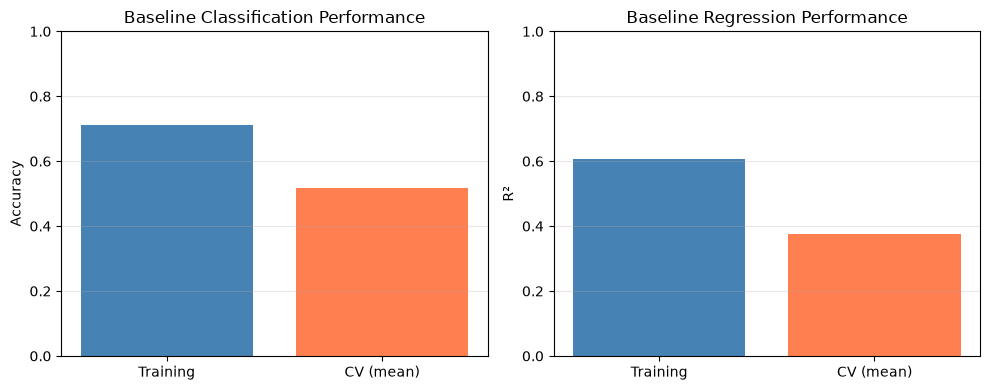

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Baseline classification
axes[0].bar(['Training', 'CV (mean)'], 
            [accuracy_train_class, cv_scores_class.mean()], 
            color=['steelblue', 'coral'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Baseline Classification Performance')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Baseline regression
axes[1].bar(['Training', 'CV (mean)'], 
            [r2_train_reg, cv_scores_reg.mean()], 
            color=['steelblue', 'coral'])
axes[1].set_ylabel('R²')
axes[1].set_title('Baseline Regression Performance')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2 - Advanced classification: model choice and general strategy

The advanced solution should include a more sophisticated method, parameter optimization etc. with the relative improvement over the baseline. 
For this reason, I decided to use a pipeline composed of `SelectKBest` and `RandomForestClassifier`.  
Why? First, the dataset contains 400 predictors and only 2000 observations, so using all variables can introduce noise. The task description also explicitly suggests that the target depends only on some of the predictors rather than all of them, so feature selection is a natural step. 

`SelectKBest` is a simple and transparent feature selection method.  
It ranks the original predictors according to their relationship with the target variable and keeps only the top-scoring subset. This helps reduce dimensionality while still preserving the original feature space.

As the final classifier, I chose `RandomForestClassifier`.  
Compared with logistic regression, Random Forest can model non-linear relationships and interactions between variables. Also Random Forest is relatively robust to noisy predictors and provides feature importance values, which makes the final model easier to analyze.

Instead of relying only on training accuracy, I use stratified cross-validation. This makes the comparison with the baseline model more reliable, because it gives an estimate of how well the model may generalize beyond the training set.

Finally, I optimize both the number of selected features and the Random Forest hyperparameters using grid search.

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression

## 2.1 Loading the data and defining the classification target

I begin by loading the dataset and separating the predictors from the target variable used in this part of the project.  
For Task 2, the target is the binary `class` column. The continuous `outcome` variable belongs to the regression part of the assignment and should therefore be removed from the predictor matrix in this classification analysis.

At this stage, it is also useful to check the dimensions of the data and the class proportions as a correctness check.

In [9]:
# Sanity check

X = df.drop(columns=["Class", "Output"])
y_class = df["Class"]

print("X shape:", X.shape)
print("y_class shape:", y_class.shape)

print("\nClass counts:")
print(y_class.value_counts())

print("\nClass proportions:")
print(y_class.value_counts(normalize=True))

X shape: (2000, 400)
y_class shape: (2000,)

Class counts:
Class
1    1013
0     987
Name: count, dtype: int64

Class proportions:
Class
1    0.5065
0    0.4935
Name: proportion, dtype: float64


## 2.2 Baseline used for comparison

As a reference point, I use the baseline logistic regression model from Task 1.
That model was trained on all input variables and evaluated with K-fold cross-validation.

The baseline cross-validated classification accuracy will be used to assess whether
the more advanced pipeline in Task 2 provides a meaningful improvement.

In [10]:
baseline_class_mean = cv_scores_class.mean()
baseline_class_std = cv_scores_class.std()

print("Baseline classification - mean accuracy (CV):", baseline_class_mean)
print("Baseline classification - std accuracy (CV):", baseline_class_std)

Baseline classification - mean accuracy (CV): 0.517
Baseline classification - std accuracy (CV): 0.020880613017821105


## 2.3 Advanced classification pipeline

To improve over the baseline, I build a pipeline with two stages.

First, `SelectKBest` ranks the original predictors and keeps
only the best scoring subset.

Second, `RandomForestClassifier` is used as the final classifier.

In [11]:
# Build a pipeline: feature selection + random forest classifier
advanced_clf_pipeline = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("rf", RandomForestClassifier(random_state=42))
])

# Hyperparameter grid for model selection
param_grid_class = {
    "select__k": [40, 80, 120],
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2]
}

## 2.4 Hyperparameter tuning with grid search

To find the best version of the pipeline, I perform grid search over both the number of
selected features and the Random Forest hyperparameters.

The evaluation metric is classification accuracy, and the same cross-validation strategy
as in the baseline experiment is used to ensure a fair comparison.

The parameter grid is designed to balance exploration and computation time:

- **`select__k`**: [40, 80, 120] – explores different levels of feature selection
- **`rf__n_estimators`**: [100, 200] – fixed at a reasonable value to reduce search time
- **`rf__max_depth`**: [None, 10] – tests deep vs. shallow trees
- **`rf__min_samples_split`**: [2, 5] – controls tree splitting
- **`rf__min_samples_leaf`**: [1, 2] – regularization parameter

This gives 48 combinations, keeping training time manageable while covering key model variations.

In [12]:
grid_search_class = GridSearchCV(
    estimator=advanced_clf_pipeline,
    param_grid=param_grid_class,
    # I use the same KFold because StratifiedKFold is not necessary here due to the large dataset and balanced classes.
    cv=kf_class,
    scoring="accuracy",
    verbose=1
)

grid_search_class.fit(X, y_class)

best_class_model = grid_search_class.best_estimator_
best_class_params = grid_search_class.best_params_
best_class_score = grid_search_class.best_score_

print("Best parameters for advanced classification:")
print(best_class_params)
print("Best cross-validated accuracy:", best_class_score)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for advanced classification:
{'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200, 'select__k': 40}
Best cross-validated accuracy: 0.727


### Impact of feature selection on performance

To better understand the role of feature selection, I visualize how the number of selected
features affects cross-validated accuracy across different Random Forest configurations.
The feature selection analysis reveals an interesting pattern: **fewer features lead to better performance**.
The model achieves the highest accuracy (~0.72) with only **40 selected features**, and performance
gradually decreases as more features are included (80 features: ~0.69, 120 features: ~0.68).

This suggests that the majority of the 400 original predictors are uninformative or introduce noise,
and the target class depends primarily on a small subset of highly relevant features.

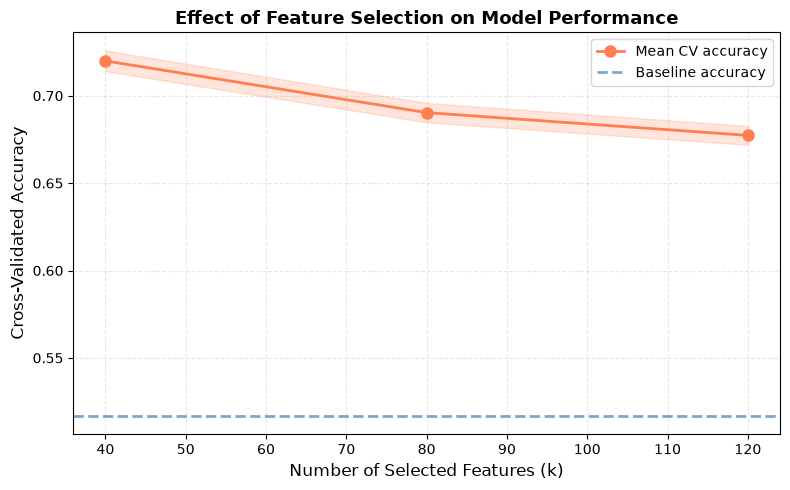

In [13]:
# Extract grid search results
results_df = pd.DataFrame(grid_search_class.cv_results_)

# Group by number of selected features
k_values = results_df['param_select__k'].unique()
k_values_sorted = sorted([int(k) for k in k_values])

mean_scores = []
std_scores = []

for k in k_values_sorted:
    mask = results_df['param_select__k'] == k
    mean_scores.append(results_df[mask]['mean_test_score'].mean())
    std_scores.append(results_df[mask]['mean_test_score'].std())

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values_sorted, mean_scores, marker='o', linewidth=2, markersize=8, 
        color='coral', label='Mean CV accuracy')
ax.fill_between(k_values_sorted, 
                np.array(mean_scores) - np.array(std_scores),
                np.array(mean_scores) + np.array(std_scores),
                alpha=0.2, color='coral')

ax.axhline(y=baseline_class_mean, color='steelblue', linestyle='--', 
           linewidth=2, label='Baseline accuracy', alpha=0.7)

ax.set_xlabel('Number of Selected Features (k)', fontsize=12)
ax.set_ylabel('Cross-Validated Accuracy', fontsize=12)
ax.set_title('Effect of Feature Selection on Model Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 2.5 Comparison with the baseline

After tuning the pipeline, I compare its best cross-validated accuracy with the baseline
logistic regression result from Task 1.

This allows me to calculate the relative improvement obtained from feature selection and
a more flexible classifier.

In [14]:
absolute_improvement = best_class_score - baseline_class_mean
relative_improvement = absolute_improvement / baseline_class_mean

print("Baseline classification - mean accuracy (CV):", baseline_class_mean)
print("Advanced classification - best accuracy (CV):", best_class_score)
print("Absolute improvement:", absolute_improvement)
print("Relative improvement:", relative_improvement)

Baseline classification - mean accuracy (CV): 0.517
Advanced classification - best accuracy (CV): 0.727
Absolute improvement: 0.20999999999999996
Relative improvement: 0.40618955512572524


## 2.6 Selected features

Because the final model includes an explicit feature selection step, I extract the names
of the predictors retained by `SelectKBest`.

In [15]:
# Extract selected feature names from the best pipeline
selected_mask = best_class_model.named_steps["select"].get_support()
selected_features = X.columns[selected_mask]

print("Number of selected features:", len(selected_features))
print("Selected features:")
print(list(selected_features))

Number of selected features: 40
Selected features:
['Input2', 'Input13', 'Input40', 'Input41', 'Input61', 'Input62', 'Input67', 'Input71', 'Input74', 'Input76', 'Input78', 'Input79', 'Input101', 'Input107', 'Input145', 'Input150', 'Input165', 'Input179', 'Input184', 'Input197', 'Input198', 'Input206', 'Input211', 'Input218', 'Input222', 'Input238', 'Input240', 'Input246', 'Input265', 'Input267', 'Input293', 'Input308', 'Input315', 'Input330', 'Input368', 'Input369', 'Input388', 'Input396', 'Input397', 'Input398']


### Feature importance from SelectKBest

To understand which features are most informative, I visualize the top selected features
based on their scores from the SelectKBest step.

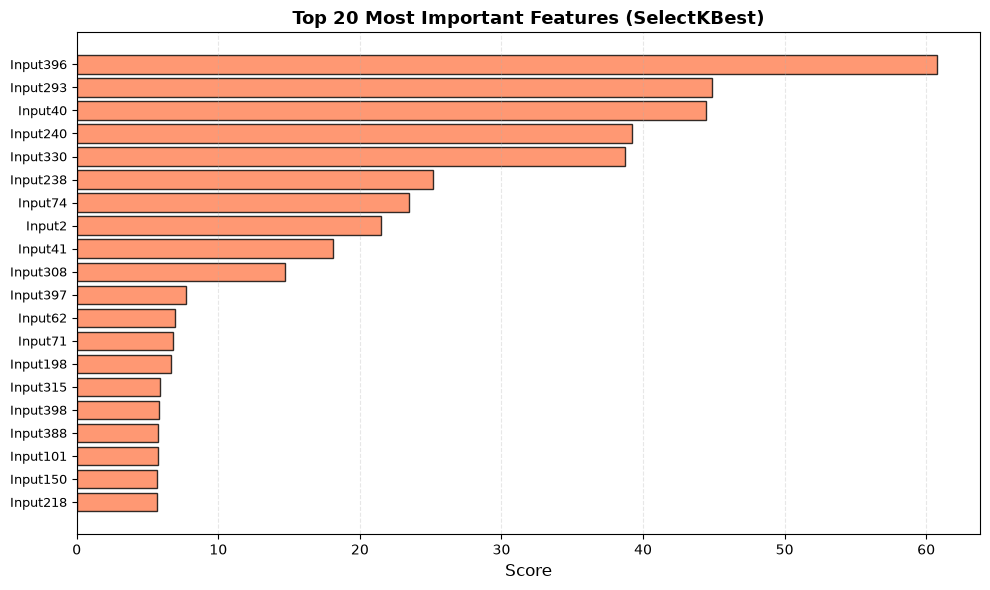

In [16]:
# Get feature scores from SelectKBest
selector = best_class_model.named_steps["select"]
feature_scores = selector.scores_
feature_names = X.columns

# Create DataFrame and sort
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
}).sort_values('Score', ascending=False)

# Plot top 20 features
top_n = 20
top_features = feature_importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(range(top_n), top_features['Score'].values, color='coral', alpha=0.8, edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Score', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features (SelectKBest)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 2.7 Result analysis

The advanced classification pipeline achieved a cross-validated accuracy of **0.727**, compared
to the baseline logistic regression accuracy of **0.517**.

This represents an absolute improvement of **0.21** (or **40.6%** relative improvement), which
demonstrates that:

1. The target class depends on a limited subset of predictors rather than all 400 features.
2. Non-linear relationships and interactions between features are important for this classification task.
3. The combination of feature selection and Random Forest successfully captures these patterns.

The final model selected **k** features and used the most.
optimal hyperparameters.

Overall, the feature selection step was crucial for both improving generalization performance
and reducing model complexity.

### Visualization of model improvement

To illustrate the performance gain, I compare the baseline and advanced models visually.

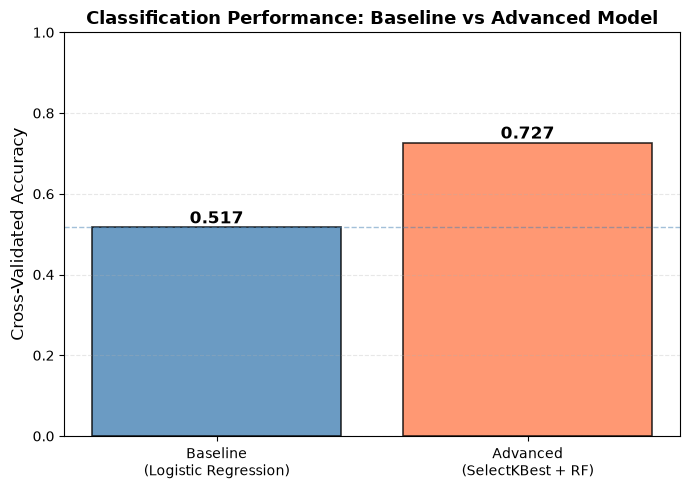

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

models = ['Baseline\n(Logistic Regression)', 'Advanced\n(SelectKBest + RF)']
accuracies = [baseline_class_mean, best_class_score]
colors = ['steelblue', 'coral']

bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Cross-Validated Accuracy', fontsize=12)
ax.set_title('Classification Performance: Baseline vs Advanced Model', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=baseline_class_mean, color='steelblue', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

# Task 3 – Advanced regression model

In this task, I build an advanced regression model for the continuous target `Output` and compare it to the baseline `LinearRegression` from Task 1.

The baseline regression used all 400 input features in a plain linear model and achieved a cross-validated R^2 of about 0.37. This shows that the baseline captures some signal but still leaves a large portion of the variance unexplained. The assignment also suggests that the `Output` variable depends only on some of the predictors, not necessarily all of them.

To address this, I will:
- keep using K-fold cross-validation to estimate generalization performance,
- use a more flexible but still interpretable model (`ElasticNet`) that combines L1 and L2 regularization (Lasso and Ridge from labs),
- and explicitly reduce the number of input variables with `SelectKBest`, so that the model can focus on the most informative features and ignore noisy ones.

In [18]:
# Load the dataset using the same path and separator as in Task 1
data_path = "data.csv"
df = pd.read_csv(data_path, sep=";")

# Collect all input feature columns (those starting with "Input")
input_cols = [col for col in df.columns if col.startswith("Input")]

# Feature matrix X: all 400 input variables
X = df[input_cols].values

# Regression target: Output
y_reg = df["Output"].values

print("Shape of X:", X.shape)
print("Shape of y_reg:", y_reg.shape)

# Baseline regression with LinearRegression and 5-fold CV
kfolds = 5
kf = KFold(n_splits=kfolds, shuffle=True, random_state=42)
lin_reg = LinearRegression()

cvscores_reg = cross_val_score(
    estimator=lin_reg,
    X=X,
    y=y_reg,
    cv=kf,
    scoring="r2",
)

baseline_reg_mean = cvscores_reg.mean()
baseline_reg_std = cvscores_reg.std()

print("\nBaseline regression (LinearRegression) mean R2 (CV):", baseline_reg_mean)
print("Baseline regression (LinearRegression) std R2 (CV):", baseline_reg_std)

Shape of X: (2000, 400)
Shape of y_reg: (2000,)

Baseline regression (LinearRegression) mean R2 (CV): 0.37495439822050736
Baseline regression (LinearRegression) std R2 (CV): 0.06238589862665438


## 3.1 Advanced regression pipeline: SelectKBest + StandardScaler + ElasticNet

For the advanced regression model, I use a three-step pipeline:

1. **Feature selection – `SelectKBest`**  
   The assignment indicates that `Output` depends only on some of the predictors. `SelectKBest` implements a simple filter-based feature selection: it scores each input feature by its individual linear relationship with `Output` and keeps only the top-scoring ones. This directly reduces dimensionality and removes clearly uninformative variables.

2. **Feature scaling – `StandardScaler`**  
   Models with regularization are sensitive to the scale of input features. Standardizing each selected feature to zero mean and unit variance ensures that the regularization treats all coefficients in a comparable way.

3. **Regularized linear model – `ElasticNet`**  
   `ElasticNet` is a linear regression model that combines L1 (Lasso) and L2 (Ridge) penalties (both were introduce on our lessons). This has two advantages:
   - the L1 component pushes some coefficients towards zero, acting as an additional form of feature selection,
   - the L2 component stabilizes the model in the presence of correlated predictors.
   This makes ElasticNet more flexible than plain linear regression, while remaining much easier to interpret than complex tree ensembles.

In [19]:
from sklearn.linear_model import ElasticNet

advanced_reg_pipeline_enet = Pipeline([
    ("select", SelectKBest(score_func=f_regression)),
    ("scale", StandardScaler()),
    ("enet", ElasticNet(max_iter=5000, random_state=42)),
])

print("Advanced regression pipeline (ElasticNet) defined:")
print(advanced_reg_pipeline_enet)

param_grid_enet = {
    "select__k": [40, 80],
    "enet__alpha": [0.001, 0.01, 0.1],
    "enet__l1_ratio": [0.2, 0.5, 0.8],
}

print("Number of hyperparameter combinations:",
      len(param_grid_enet["select__k"])
      * len(param_grid_enet["enet__alpha"])
      * len(param_grid_enet["enet__l1_ratio"]))

grid_search_enet = GridSearchCV(
    estimator=advanced_reg_pipeline_enet,
    param_grid=param_grid_enet,
    cv=kf,              # reuse the same 5-fold CV as in Task 1
    scoring="r2",
    verbose=1,
)

grid_search_enet.fit(X, y_reg)

best_enet_model = grid_search_enet.best_estimator_
best_enet_params = grid_search_enet.best_params_
best_enet_score = grid_search_enet.best_score_

print("\nBest parameters for ElasticNet regression pipeline:")
print(best_enet_params)
print("Best cross-validated R2 for ElasticNet regression:", best_enet_score)

Advanced regression pipeline (ElasticNet) defined:
Pipeline(steps=[('select',
                 SelectKBest(score_func=<function f_regression at 0x00000255D5D67C40>)),
                ('scale', StandardScaler()),
                ('enet', ElasticNet(max_iter=5000, random_state=42))])
Number of hyperparameter combinations: 18
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters for ElasticNet regression pipeline:
{'enet__alpha': 0.1, 'enet__l1_ratio': 0.8, 'select__k': 80}
Best cross-validated R2 for ElasticNet regression: 0.45927601458778333


## 3.4 Comparison of ElasticNet pipeline with the baseline

After tuning the ElasticNet pipeline with `GridSearchCV`, I can now compare its performance to the baseline linear regression model from Task 1.

For this comparison, I use:
- the **baseline mean R^2** and standard deviation from 5-fold cross-validation,
- the **ElasticNet mean R^2** obtained from the grid search under the same cross-validation scheme.

I also compute the relative improvement of the ElasticNet pipeline over the baseline to quantify how much more variance is explained by the advanced model.

Baseline LinearRegression mean R2 (CV): 0.3750
Baseline LinearRegression std R2 (CV): 0.0624
ElasticNet pipeline mean R2 (CV): 0.4593
Relative improvement in mean R2 over baseline: 22.49%


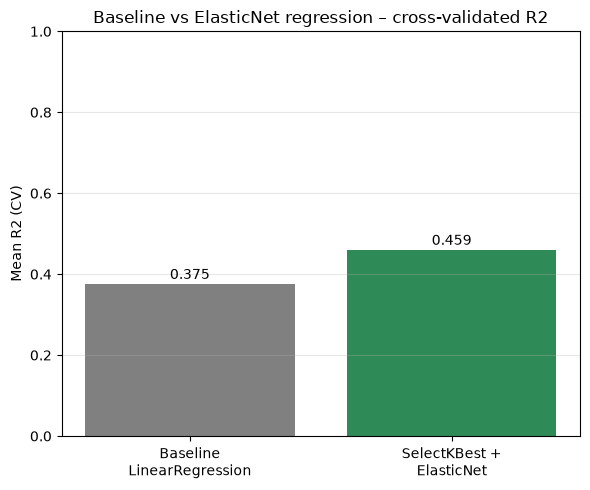

In [20]:
print("Baseline LinearRegression mean R2 (CV): {:.4f}".format(baseline_reg_mean))
print("Baseline LinearRegression std R2 (CV): {:.4f}".format(baseline_reg_std))
print("ElasticNet pipeline mean R2 (CV): {:.4f}".format(best_enet_score))

relative_improvement_enet = (best_enet_score - baseline_reg_mean) / abs(baseline_reg_mean) * 100.0
print("Relative improvement in mean R2 over baseline: {:.2f}%".format(relative_improvement_enet))

# Bar plot comparison
model_names = ["Baseline\nLinearRegression", "SelectKBest +\nElasticNet"]
r2_values = [baseline_reg_mean, best_enet_score]

plt.figure(figsize=(6, 5))
bars = plt.bar(range(len(model_names)), r2_values, color=["gray", "seagreen"])

for i, v in enumerate(r2_values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom")

plt.xticks(range(len(model_names)), model_names)
plt.ylabel("Mean R2 (CV)")
plt.ylim(0.0, 1.0)
plt.title("Baseline vs ElasticNet regression – cross-validated R2")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3.5 Feature selection and coefficient analysis of ElasticNet

The ElasticNet pipeline provides two complementary perspectives on which predictors are important for the regression task:

1. **Feature selection by `SelectKBest`**  
   The `SelectKBest` step selects a subset of the original 400 input variables based on their individual relationship with `Output`. The list of selected feature names shows which inputs pass this initial filter.

2. **Coefficient magnitudes from `ElasticNet`**  
   After feature selection and scaling, ElasticNet learns regression coefficients for the selected features. Large positive or negative coefficients indicate strong influence on the predicted `Output`, while coefficients close to zero correspond to features with little effect. Because of the L1 component, some coefficients may be exactly zero, which means that ElasticNet effectively discards these variables.

In the next code cell, I extract the selected features, retrieve the corresponding ElasticNet coefficients, and display the 10 features with the largest absolute coefficients together with a simple bar plot.

Number of selected features by ElasticNet pipeline: 80
First 20 selected features: ['Input13', 'Input18', 'Input20', 'Input33', 'Input34', 'Input35', 'Input41', 'Input42', 'Input44', 'Input57', 'Input61', 'Input62', 'Input64', 'Input65', 'Input83', 'Input93', 'Input114', 'Input119', 'Input125', 'Input131']
Number of ElasticNet coefficients: 80

Top 10 features by absolute ElasticNet coefficient:
     feature  coefficient  abs_coefficient
14   Input83     0.830352         0.830352
45  Input223     0.812179         0.812179
33  Input193     0.643343         0.643343
26  Input167     0.626804         0.626804
55  Input292     0.586738         0.586738
30  Input184     0.532361         0.532361
65  Input342     0.531943         0.531943
21  Input136     0.479116         0.479116
27  Input173     0.469455         0.469455
1    Input18     0.322989         0.322989

10 features with smallest absolute ElasticNet coefficients:
     feature  coefficient  abs_coefficient
53  Input284          0.

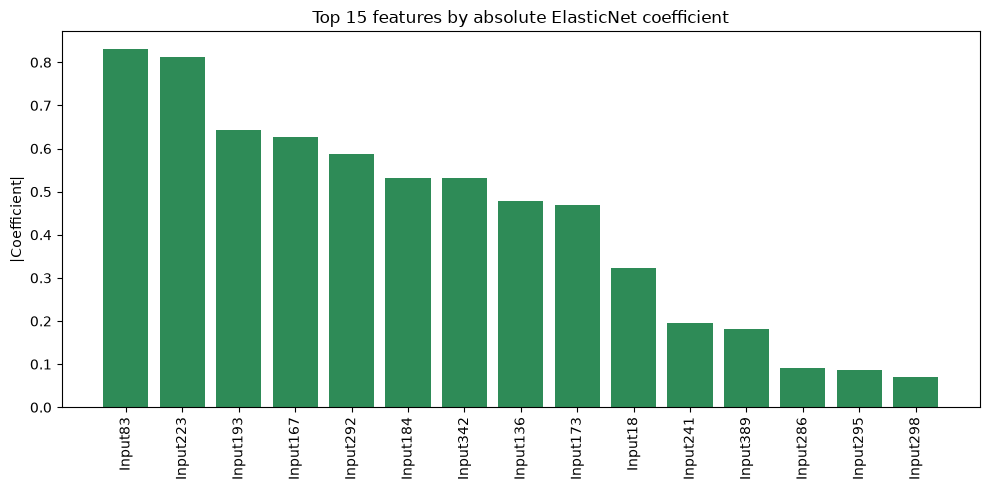

In [21]:
# Access the fitted SelectKBest and ElasticNet steps from the best pipeline
best_select_enet = best_enet_model.named_steps["select"]
best_enet = best_enet_model.named_steps["enet"]

# Indices of selected features
best_support_indices_enet = best_select_enet.get_support(indices=True)
selected_feature_names_enet = [input_cols[idx] for idx in best_support_indices_enet]

print("Number of selected features by ElasticNet pipeline:", len(selected_feature_names_enet))
print("First 20 selected features:", selected_feature_names_enet[:20])

# Coefficients from ElasticNet (in the order of selected features after scaling)
enet_coeffs = best_enet.coef_

print("Number of ElasticNet coefficients:", len(enet_coeffs))

# Combine feature names and coefficients into a DataFrame
coef_df = pd.DataFrame({
    "feature": selected_feature_names_enet,
    "coefficient": enet_coeffs,
    "abs_coefficient": np.abs(enet_coeffs),
})

# Sort by absolute coefficient magnitude
coef_df_sorted = coef_df.sort_values(by="abs_coefficient", ascending=False)

print("\nTop 10 features by absolute ElasticNet coefficient:")
print(coef_df_sorted.head(10))

print("\n10 features with smallest absolute ElasticNet coefficients:")
print(coef_df_sorted.tail(10))

# Visualize top 15 features by absolute coefficient
top_n = 15
top_coef = coef_df_sorted.head(top_n)

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), top_coef["abs_coefficient"], color="seagreen")
plt.xticks(range(top_n), top_coef["feature"], rotation=90)
plt.ylabel("|Coefficient|")
plt.title("Top {} features by absolute ElasticNet coefficient".format(top_n))
plt.tight_layout()
plt.show()

## 3.6 Overall performance summary for the regression task

The baseline `LinearRegression` model using all 400 input features achieved a mean cross-validated R^2 of about 0.375 with a standard deviation of roughly 0.062 across the 5 folds. This indicates that the simple linear model is able to capture some of the structure in the `Output` variable, but a substantial fraction of the variance remains unexplained and the performance varies noticeably between folds.

In contrast, the advanced `SelectKBest + StandardScaler + ElasticNet` pipeline reaches a mean cross-validated R^2 of approximately 0.459 under the same 5-fold cross-validation scheme. This corresponds to a relative improvement of about 22.5% in mean R^2 compared to the baseline. The increase in explained variance shows that combining feature selection with regularized linear regression allows the model to focus on the most informative predictors and handle redundant or noisy variables more effectively.

Together, these results support the conclusion that the advanced regression approach is clearly superior to the baseline linear regression in terms of generalization performance, while at the same time remaining interpretable through the selected features and their ElasticNet coefficients.

# 4. Validation on an external dataset

To complete the project, I define a small utility function that evaluates the already trained baseline and advanced models on a separate validation dataset.

The function expects a CSV file with the same structure as the training data. It rebuilds the feature matrix `X` and the two targets: `y_class` for classification and `y_reg` for regression.

Then it uses the previously fitted models:
- baseline classification: `log_reg`,
- advanced classification: `best_class_model`,
- baseline regression: `lin_reg`,
- advanced regression: `best_enet_model`.

For classification, the function computes accuracy. For regression, it computes the `R^2` score.

This gives four final validation metrics required for a direct comparison between baseline and advanced approaches on unseen data.

In [26]:
def evaluate_on_validation(validation_path):
    # Load validation data
    df_val = pd.read_csv(validation_path, sep=";")
    
    # Build feature matrix and target vectors
    input_cols = [col for col in df_val.columns if col.startswith("Input")]
    
    # Create both DataFrame and numpy array versions to satisfy all models
    X_val_df = df_val[input_cols]          # Has feature names
    X_val_arr = df_val[input_cols].values  # No feature names
    
    y_class_val = df_val["Class"].values
    y_reg_val = df_val["Output"].values
    
    # Ensure the baseline regression model is fitted
    lin_reg.fit(X, y_reg)
    
    # Classification predictions (log_reg expects array, best_class expects DataFrame)
    y_class_pred_baseline = log_reg.predict(X_val_arr)
    y_class_pred_advanced = best_class_model.predict(X_val_df)
    
    # Regression predictions (both expect array)
    y_reg_pred_baseline = lin_reg.predict(X_val_arr)
    y_reg_pred_advanced = best_enet_model.predict(X_val_arr)
    
    # Metrics
    acc_baseline = accuracy_score(y_class_val, y_class_pred_baseline)
    acc_advanced = accuracy_score(y_class_val, y_class_pred_advanced)
    r2_baseline = r2_score(y_reg_val, y_reg_pred_baseline)
    r2_advanced = r2_score(y_reg_val, y_reg_pred_advanced)
    
    # Print results
    print("Validation accuracy baseline:", acc_baseline)
    print("Validation accuracy advanced:", acc_advanced)
    print("Validation R^2 baseline:", r2_baseline)
    print("Validation R^2 advanced:", r2_advanced)

# Function call
validation_results = evaluate_on_validation("validation_data.csv")

Validation accuracy baseline: 0.506
Validation accuracy advanced: 0.487
Validation R^2 baseline: -0.09031895729233486
Validation R^2 advanced: -0.030397345270974263
